# Car Price Prediction with Machine Learning

Predicting the selling price of a used car from features such as brand, age, mileage (km driven), fuel type, transmission, seller type and ownership history.

**Tech stack:** Python, pandas, scikit-learn, matplotlib, seaborn

**Workflow:**
1. Load the dataset
2. Data cleaning
3. Feature engineering
4. Exploratory data analysis (EDA)
5. Encoding categorical variables
6. Correlation heatmap
7. Train/test split
8. Train multiple regression models
9. Evaluate with MAE, RMSE, R²
10. Feature importance for the best model


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the dataset

**Dataset note:** The task points to the well-known *"Vehicle dataset from CarDekho"* on Kaggle
(columns: `name`, `year`, `selling_price`, `km_driven`, `fuel`, `seller_type`, `transmission`, `owner`).

This notebook was built in a sandboxed environment with no internet access, so the real Kaggle
CSV could not be downloaded here. In its place, `generate_dataset.py` (included alongside this
notebook) programmatically builds a synthetic dataset with **the exact same columns**, realistic
Indian car brands/models, price ranges, and the same kinds of messiness a real scraped Kaggle file
has (inconsistent casing like `"Petrol"` vs `"petrol"`, stray whitespace, duplicate rows, and a
handful of missing values).

**To use the real data instead:** download `CAR DETAILS FROM CAR DEKHO.csv` from Kaggle, place it
at `data/car_data_raw.csv` with the same column names, and skip straight to the `pd.read_csv` cell
below — every other cell works unchanged.


In [2]:
df = pd.read_csv("data/car_data_raw.csv")
print("Shape:", df.shape)
df.head()

Shape: (1236, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Audi Q3 2021,2021,2973200.0,56528.0,DIESEL,individual,MANUAL,Test Drive Car
1,Volkswagen Vento 2019,2019,532900.0,62176.0,Diesel,Dealer,MANUAL,First Owner
2,Maruti Swift 2014,2014,155800.0,121748.0,Petrol,Individual,MANUAL,Second Owner
3,Audi A4 2007,2007,447300.0,213348.0,DIESEL,Dealer,manual,First Owner
4,Volkswagen Polo 2021,2021,551400.0,43846.0,PETROL,Dealer,Manual,Second Owner


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           1236 non-null   str    
 1   year           1236 non-null   int64  
 2   selling_price  1230 non-null   float64
 3   km_driven      1212 non-null   float64
 4   fuel           1224 non-null   str    
 5   seller_type    1236 non-null   str    
 6   transmission   1236 non-null   str    
 7   owner          1236 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 77.4 KB


In [4]:
df.isna().sum()

name              0
year              0
selling_price     6
km_driven        24
fuel             12
seller_type       0
transmission      0
owner             0
dtype: int64

## 2. Data cleaning

Steps:
- Strip stray whitespace from text columns
- Standardise categorical casing (e.g. `"Petrol"` / `"petrol"` / `"PETROL"` -> `"Petrol"`)
- Remove duplicate rows
- Handle missing values (impute numeric with median, categorical with mode, drop rows with a
  missing target since we can't train on an unknown price)


In [5]:
df["name"] = df["name"].astype(str).str.strip()

for col in ["fuel", "seller_type", "transmission", "owner"]:
    df[col] = df[col].astype(str).str.strip().str.title()

# a couple of abbreviations don't "Title Case" nicely (Cng -> CNG, Lpg -> LPG)
df["fuel"] = df["fuel"].replace({"Cng": "CNG", "Lpg": "LPG"})

print("Unique fuel values after cleaning:", df["fuel"].unique())
print("Unique transmission values after cleaning:", df["transmission"].unique())

Unique fuel values after cleaning: <StringArray>
['Diesel', 'Petrol', 'Electric', 'CNG', nan, 'LPG']
Length: 6, dtype: str
Unique transmission values after cleaning: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


In [6]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows ({before} -> {len(df)})")

Removed 33 duplicate rows (1236 -> 1203)


In [7]:
print("Missing values before imputation:")
print(df.isna().sum())

# numeric column -> median; categorical -> mode
df["km_driven"] = df["km_driven"].fillna(df["km_driven"].median())
df["fuel"] = df["fuel"].fillna(df["fuel"].mode()[0])

# selling_price is our target - a row with no known price isn't useful for training
df = df.dropna(subset=["selling_price"]).reset_index(drop=True)

print("\nMissing values after cleaning:")
print(df.isna().sum())
print("\nFinal shape:", df.shape)

Missing values before imputation:
name              0
year              0
selling_price     6
km_driven        24
fuel             12
seller_type       0
transmission      0
owner             0
dtype: int64

Missing values after cleaning:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Final shape: (1197, 8)


## 3. Feature engineering

- **`car_age`**: derived from `year` (a car's age is usually far more predictive of price than the
  raw model year, and generalises better to future years)
- **`brand`**: extracted from the first token of the `name` column (e.g. `"Maruti Swift 2014"` ->
  `"Maruti"`), since brand has a big effect on resale value


In [8]:
CURRENT_YEAR = 2024

df["car_age"] = CURRENT_YEAR - df["year"]
df["brand"] = df["name"].str.split().str[0]

df[["name", "year", "car_age", "brand"]].head(8)

,name,year,car_age,brand
0,Audi Q3 2021,2021,3,Audi
1,Volkswagen Vento 2019,2019,5,Volkswagen
2,Maruti Swift 2014,2014,10,Maruti
3,Audi A4 2007,2007,17,Audi
4,Volkswagen Polo 2021,2021,3,Volkswagen
5,Ford EcoSport 2013,2013,11,Ford
6,Ford Endeavour 2015,2015,9,Ford
7,Skoda Rapid 2017,2017,7,Skoda


In [9]:
print("Number of distinct brands:", df["brand"].nunique())
df["brand"].value_counts()

Number of distinct brands: 12


brand
Maruti        168
Hyundai       163
Tata          146
Ford          126
Mahindra      107
Toyota        101
Honda         101
Renault        91
Volkswagen     78
Skoda          46
Audi           41
BMW            29
Name: count, dtype: int64

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of selling prices


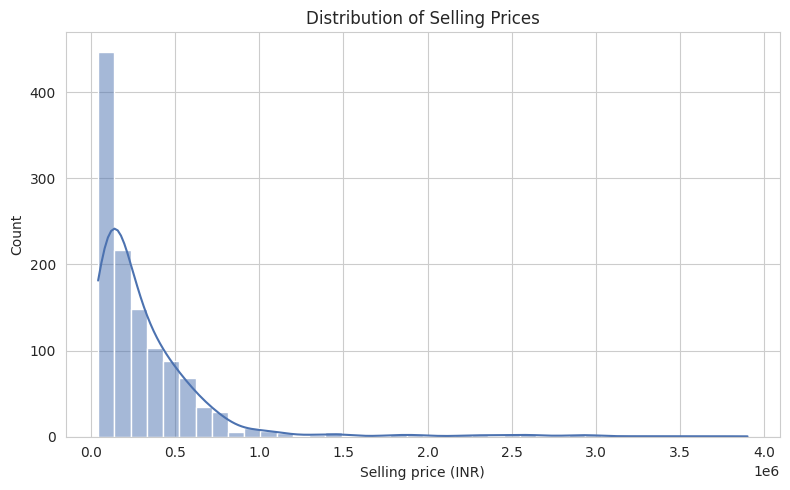

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["selling_price"], kde=True, bins=40, ax=ax, color="#4C72B0")
ax.set_title("Distribution of Selling Prices")
ax.set_xlabel("Selling price (INR)")
plt.tight_layout()
plt.show()

### 4.2 Selling price vs. fuel type

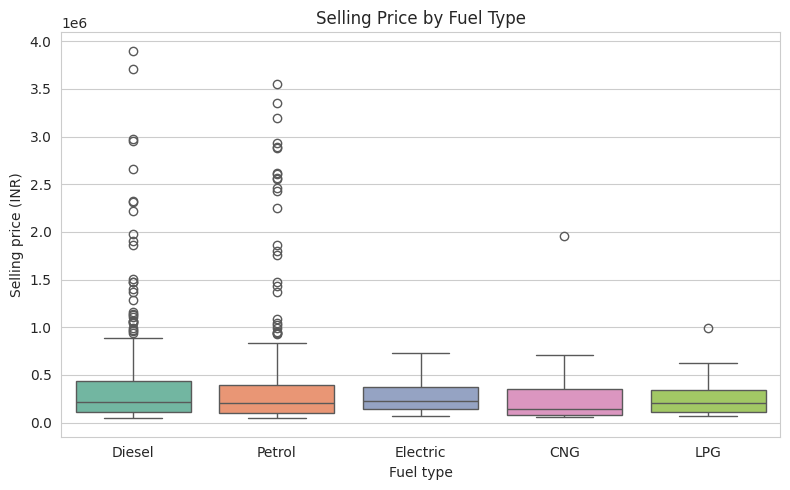

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="fuel", y="selling_price", hue="fuel", palette="Set2", legend=False, ax=ax)
ax.set_title("Selling Price by Fuel Type")
ax.set_xlabel("Fuel type")
ax.set_ylabel("Selling price (INR)")
plt.tight_layout()
plt.show()

### 4.3 Selling price vs. car age

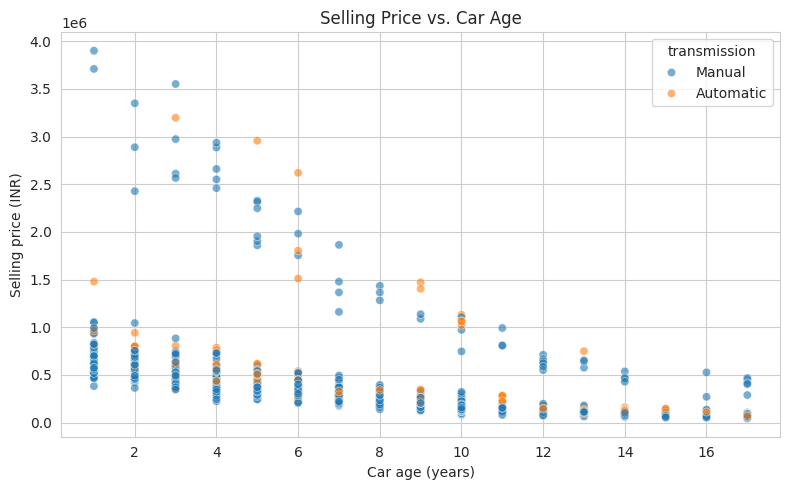

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="car_age", y="selling_price", hue="transmission", alpha=0.6, ax=ax)
ax.set_title("Selling Price vs. Car Age")
ax.set_xlabel("Car age (years)")
ax.set_ylabel("Selling price (INR)")
plt.tight_layout()
plt.show()

## 5. Encode categorical variables

`brand`, `fuel`, `seller_type`, `transmission` and `owner` are nominal categories with no
inherent order, so we one-hot encode them with `pd.get_dummies` (dropping the first level of each
to avoid the dummy-variable trap). The original `name` and `year` columns are dropped — `name` is
just free text we've already mined for `brand`, and `year` is now redundant with `car_age`.


In [13]:
model_df = df.drop(columns=["name", "year"])

categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", model_df.shape)
model_df.head()

Shape after encoding: (1197, 25)


,selling_price,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,brand_BMW,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,2973200.0,56528.0,3,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,532900.0,62176.0,5,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,155800.0,121748.0,10,False,False,False,True,True,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False
3,447300.0,213348.0,17,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,551400.0,43846.0,3,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


## 6. Feature correlation heatmap

A quick look at how the numeric features relate to each other and to the target before modelling.


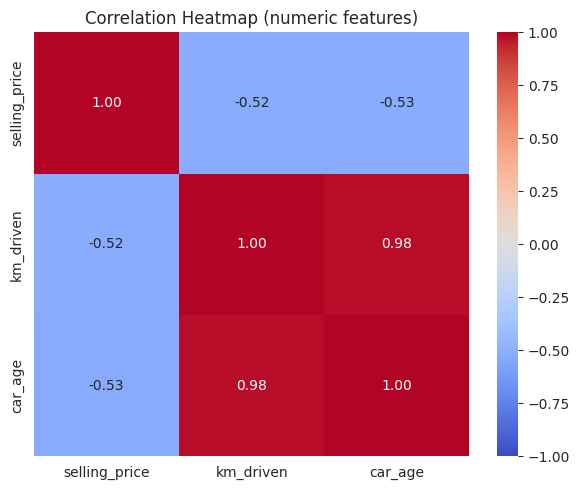

In [14]:
numeric_cols = ["selling_price", "km_driven", "car_age"]
corr = model_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.show()

## 7. Train / test split


In [15]:
X = model_df.drop(columns=["selling_price"])
y = model_df["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (957, 24)
Test shape : (240, 24)


## 8. Train regression models

We train three regressors of increasing complexity and compare them:
- **Linear Regression** — simple, interpretable baseline
- **Random Forest Regressor** — bagged ensemble of decision trees, captures non-linearities
- **Gradient Boosting Regressor** — boosted ensemble of trees, often the strongest tabular model


In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

print("All models trained.")

All models trained.


## 9. Evaluate models: MAE, RMSE, R²


In [17]:
rows = []
for name, pred in predictions.items():
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    rows.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,110587.859646,252043.974371,0.769679
1,Gradient Boosting,101295.249207,325455.929818,0.615970
2,Random Forest,114720.064583,338976.584845,0.583399


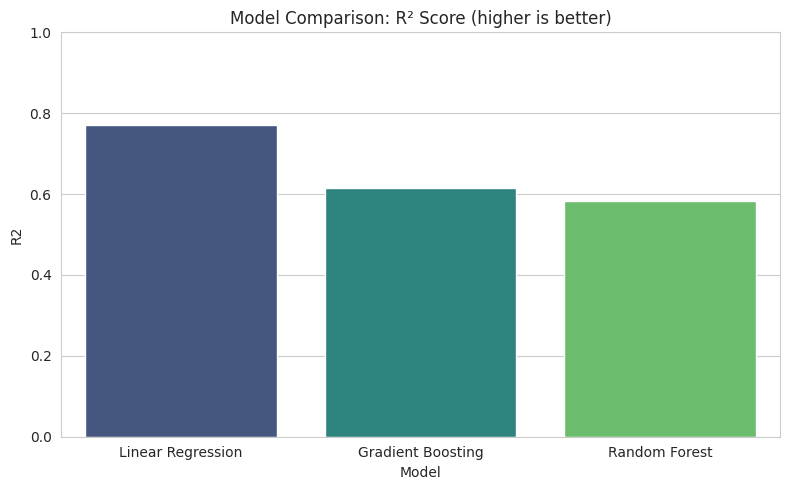

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="R2", hue="Model", palette="viridis", legend=False, ax=ax)
ax.set_title("Model Comparison: R² Score (higher is better)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [19]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best performing model: {best_model_name}")
print(results_df.iloc[0])

Best performing model: Linear Regression
Model    Linear Regression
MAE          110587.859646
RMSE         252043.974371
R2                0.769679
Name: 0, dtype: object


## 10. Feature importance (best model)

Tree-based models (Random Forest / Gradient Boosting) expose `feature_importances_` directly. If
the best model is Linear Regression instead, we fall back to showing the absolute standardised
coefficients, which play the same role for a linear model.


brand_Renault                 1.228985e+06
brand_Maruti                  1.199923e+06
brand_Tata                    1.177678e+06
brand_Hyundai                 1.162632e+06
brand_Ford                    1.147411e+06
brand_Honda                   1.140638e+06
brand_Volkswagen              1.117065e+06
brand_Mahindra                1.103024e+06
brand_Skoda                   1.065792e+06
brand_Toyota                  1.056132e+06
owner_Fourth & Above Owner    1.305087e+05
owner_Third Owner             7.259054e+04
owner_Test Drive Car          7.095882e+04
transmission_Manual           6.805029e+04
fuel_Diesel                   4.044961e+04
dtype: float64

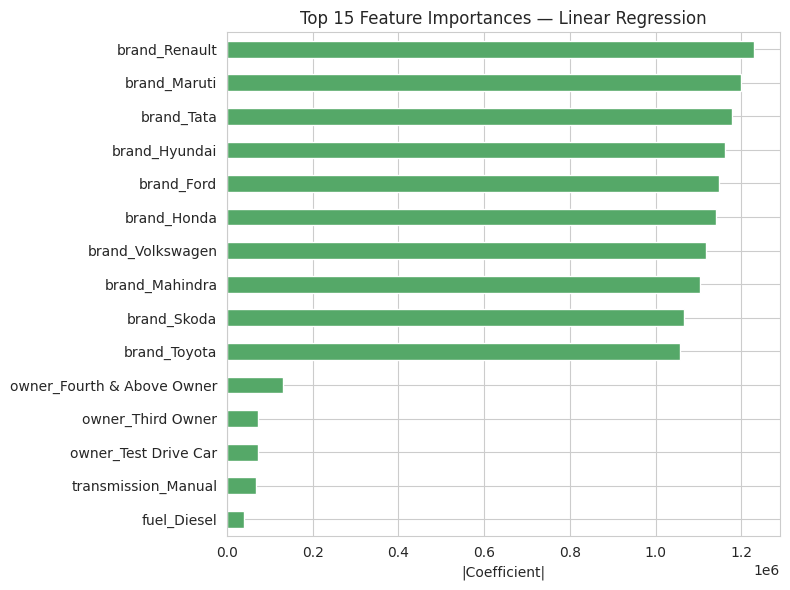

In [20]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importance_label = "Feature importance"
else:
    # for a linear model, coefficient magnitude (on comparably-scaled features) is
    # the closest analogue to feature importance
    importances = pd.Series(np.abs(best_model.coef_), index=X.columns)
    importance_label = "|Coefficient|"

top_importances = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_importances.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
ax.set_xlabel(importance_label)
plt.tight_layout()
plt.show()

top_importances

## Summary

- Cleaned a messy raw dataset (inconsistent categorical casing, duplicates, missing values)
- Engineered `car_age` and `brand` features
- Explored price distribution, price vs. fuel type, and price vs. age
- One-hot encoded categorical variables and inspected feature correlations
- Trained and compared Linear Regression, Random Forest, and Gradient Boosting regressors
- Evaluated each with MAE, RMSE and R², and visualised feature importance for the winner

**Next steps you could try:** hyperparameter tuning (e.g. `GridSearchCV`), log-transforming
`selling_price` before fitting the linear model, adding a `mileage`/`engine`/`seats` column if your
real dataset has one, or trying `XGBoost`/`LightGBM` for a stronger boosted baseline.
